In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!rm -rf "/content/ECG signals"

In [4]:
!cp -r "/content/drive/MyDrive/ECG signals" /content/

In [5]:
!ls /content/"ECG signals"

ptbxl_database.csv  records100	scp_statements.csv


In [6]:
!pip install wfdb
!pip install transformers sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 121.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.


In [7]:
import os
import ast
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow.keras as keras

sns.set_style('darkgrid')

In [8]:
PATH_TO_DATA = "/content/ECG signals/"

ECG_df = pd.read_csv(os.path.join(PATH_TO_DATA, 'ptbxl_database.csv'), index_col='ecg_id')
ECG_df.scp_codes = ECG_df.scp_codes.apply(lambda x: ast.literal_eval(x))
ECG_df.patient_id = ECG_df.patient_id.astype(int)
ECG_df.nurse = ECG_df.nurse.astype('Int64')
ECG_df.site = ECG_df.site.astype('Int64')
ECG_df.validated_by = ECG_df.validated_by.astype('Int64')

SCP_df = pd.read_csv(os.path.join(PATH_TO_DATA, 'scp_statements.csv'), index_col=0)
SCP_df = SCP_df[SCP_df.diagnostic == 1]

diagnostic_dict = SCP_df.diagnostic_class.to_dict()

In [9]:
def diagnostic_class(scp_codes):
    classes = set()
    for code in scp_codes.keys():
        if code in SCP_df.index:
            classes.add(SCP_df.loc[code].diagnostic_class)
    return list(classes)

ECG_df['scp_classes'] = ECG_df.scp_codes.apply(diagnostic_class)
ECG_df[['scp_codes','scp_classes']].head()

,scp_codes,scp_classes
ecg_id,,
1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",[NORM]
2,"{'NORM': 80.0, 'SBRAD': 0.0}",[NORM]
3,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
4,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
5,"{'NORM': 100.0, 'SR': 0.0}",[NORM]


In [10]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(os.path.join(path, f)) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(os.path.join(path, f)) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data
sampling_rate = 100

In [11]:
ECG_data = np.load("/content/drive/MyDrive/ECG_data.npy")
ECG_data.shape

(21799, 1000, 12)

In [12]:
priority = ['MI', 'STTC', 'CD', 'HYP', 'NORM']

labels = []
for i in ECG_df.index:
    classes = ECG_df.loc[i].scp_classes
    if len(classes) == 0:
        labels.append('NORM')
    else:
        for p in priority:
            if p in classes:
                labels.append(p)
                break

Z = pd.get_dummies(labels)
Z.index = ECG_df.index

In [13]:
# enforcing consistent column order so argmax indices are always correct
class_names = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
Z = Z.reindex(columns=class_names, fill_value=0)

In [14]:
print(Z.sum())

NORM    9480
MI      5469
STTC    3896
CD      2417
HYP      537
dtype: int64


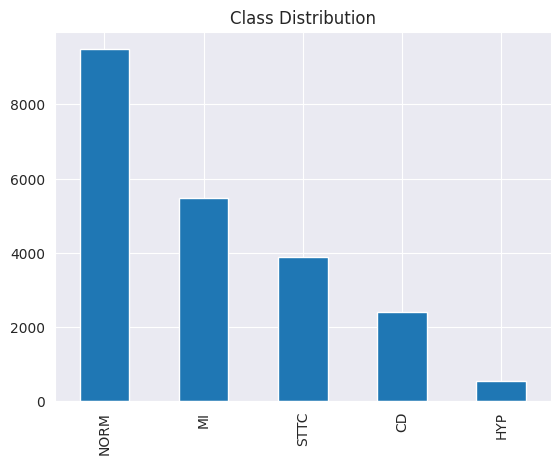

In [15]:
Z.sum().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

In [16]:
X = pd.DataFrame(index=ECG_df.index)

X['age'] = ECG_df.age
X.age.fillna(0, inplace=True)

X['sex'] = ECG_df.sex.astype(float)
X.sex.fillna(0, inplace=True)

X['height'] = ECG_df.height
X.loc[X.height < 50, 'height'] = np.nan
X.height.fillna(0, inplace=True)

X['weight'] = ECG_df.weight
X.weight.fillna(0, inplace=True)

X['BMI'] = X['weight'] / ((X['height'] / 100) ** 2)
X['BMI'] = X['BMI'].replace([np.inf, -np.inf], 0)
X['BMI'] = X['BMI'].fillna(0)

X['height_norm'] = X['height'] / 200
X['weight_norm'] = X['weight'] / 150

X = X.drop(columns=['height', 'weight'])

X['BMI'] = X['BMI'].replace(0, np.nan)
X['BMI'] = X['BMI'].fillna(X['BMI'].mean())

X['ecg_mean'] = ECG_data.mean(axis=(1,2))
X['ecg_std'] = ECG_data.std(axis=(1,2))

X['has_text'] = 0
X.loc[ECG_df.index[:500], 'has_text'] = 1
X = X.fillna(0)

/tmp/ipykernel_546/1643231176.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X.age.fillna(0, inplace=True)
/tmp/ipykernel_546/1643231176.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original 

In [ ]:
text_data = ECG_df.report.fillna("")

!pip install transformers sentencepiece
from transformers import MarianMTModel, MarianTokenizer

model_name = "Helsinki-NLP/opus-mt-de-en"
tokenizer = MarianTokenizer.from_pretrained(model_name)
translation_model = MarianMTModel.from_pretrained(model_name)

def translate_texts(texts, batch_size=32):
    translated = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size].tolist()
        tokens = tokenizer(batch, return_tensors="pt", padding=True, truncation=True)
        outputs = translation_model.generate(**tokens)
        translated_batch = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        translated.extend(translated_batch)
    return translated

text_data_en = translate_texts(text_data.iloc[:500])
text_data_en = pd.Series(text_data_en)

In [17]:
text_clean = pd.read_csv("/content/drive/MyDrive/text_clean_500.csv").iloc[:, 0]
text_clean.head()

0               sinus rhythm peripheral low
1    sinus bradycardia otherwise normal ekg
2                   sinus rhythm normal ekg
3                   sinus rhythm normal ekg
4                   sinus rhythm normal ekg
Name: 0, dtype: str

In [18]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
custom_stopwords = {'ekg','ecg','type','otherwise','non','specific'}

def clean_text_advanced(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    words = [
        w for w in words
        if w.isascii()
        and w not in stop_words
        and w not in custom_stopwords
        and len(w) > 2
    ]
    return " ".join(words)

text_clean = text_clean.apply(clean_text_advanced)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [19]:
from collections import Counter

all_words = []
for text in text_clean:
    words = text.split()
    all_words.extend(words)

word_counts = Counter(all_words)

total_reports = len(text_clean)
total_words = len(all_words)
unique_words = len(word_counts)

report_lengths = [len(t.split()) for t in text_clean]

print("Number of reports:", total_reports)
print("Total words:", total_words)
print("Unique words (vocabulary size):", unique_words)
print("Average words per report:", np.mean(report_lengths))
print("Maximum report length:", np.max(report_lengths))
print("Minimum report length:", np.min(report_lengths))

top_words = word_counts.most_common(20)

print("\nTop 20 most frequent words:")
for word, count in top_words:
    print(word, count)

Number of reports: 500
Total words: 2840
Unique words (vocabulary size): 115
Average words per report: 5.68
Maximum report length: 26
Minimum report length: 0

Top 20 most frequent words:
sinus 412
rhythm 363
normal 263
left 105
nonspecific 47
block 44
abnormal 42
myocardial 42
qrst 38
sinusrytm 38
inferior 37
elaxel 35
right 33
waves 33
atrial 31
due 29
wave 29
avl 27
ventricular 25
segments 25


In [20]:
ECG_df['report_en'] = None
ECG_df.loc[ECG_df.index[:500], 'report_en'] = text_clean.values

X['report_length'] = 0
X.loc[ECG_df.index[:500], 'report_length'] = text_clean.apply(len).values

In [21]:
text_full = ["no report"] * len(ECG_df)

for i in range(500):
    text_full[i] = text_clean.iloc[i]

text_full = pd.Series(text_full)

In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 5000
max_len = 100

tokenizer_text = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer_text.fit_on_texts(text_full)
sequences = tokenizer_text.texts_to_sequences(text_full)
text_padded = pad_sequences(sequences, maxlen=max_len, padding='post')
text_padded.shape

(21799, 100)

In [23]:
# ECG Z-score normalization, also did lead-wise normalization
ECG_data = (ECG_data - ECG_data.mean(axis=1, keepdims=True)) / \
           (ECG_data.std(axis=1, keepdims=True) + 1e-8)

In [24]:
train_idx = ECG_df[ECG_df.strat_fold <= 8].index
val_idx   = ECG_df[ECG_df.strat_fold == 9].index
test_idx  = ECG_df[ECG_df.strat_fold == 10].index

In [25]:
train_pos = ECG_df.index.get_indexer(train_idx)
val_pos   = ECG_df.index.get_indexer(val_idx)
test_pos  = ECG_df.index.get_indexer(test_idx)

X_ecg_train_raw = ECG_data[train_pos]
X_ecg_val       = ECG_data[val_pos]
X_ecg_test      = ECG_data[test_pos]

X_meta_train_raw = X.loc[train_idx].values
X_meta_val       = X.loc[val_idx].values
X_meta_test      = X.loc[test_idx].values

X_text_train_raw = text_padded[train_pos]
X_text_val       = text_padded[val_pos]
X_text_test      = text_padded[test_pos]

y_train_raw = Z.loc[train_idx].values
y_val       = Z.loc[val_idx].values
y_test      = Z.loc[test_idx].values

In [26]:
# Balancing
np.random.seed(42)

TARGET = 4000

y_train_labels = np.argmax(y_train_raw, axis=1)
print("Before balancing:", Counter(y_train_labels))

balanced_idx = []
for cls in range(5):
    idx = np.where(y_train_labels == cls)[0]
    if len(idx) >= TARGET:
        chosen = np.random.choice(idx, TARGET, replace=False)  #Majority classes reduced
    else:
        chosen = np.random.choice(idx, TARGET, replace=True) #Minority classes duplicated
    balanced_idx.append(chosen)

balanced_idx = np.concatenate(balanced_idx)
np.random.shuffle(balanced_idx)

X_ecg_train  = X_ecg_train_raw[balanced_idx].copy()
X_meta_train = X_meta_train_raw[balanced_idx]
X_text_train = X_text_train_raw[balanced_idx]
y_train      = y_train_raw[balanced_idx]

noise = np.random.normal(0, 0.005, X_ecg_train.shape) #Adding Gaussian noise
X_ecg_train = X_ecg_train + noise

print("After balancing:", Counter(np.argmax(y_train, axis=1)))

Before balancing: Counter({np.int64(0): 7577, np.int64(1): 4379, np.int64(2): 3131, np.int64(3): 1915, np.int64(4): 416})
After balancing: Counter({np.int64(4): 4000, np.int64(1): 4000, np.int64(2): 4000, np.int64(0): 4000, np.int64(3): 4000})


In [27]:
# class weights
from sklearn.utils.class_weight import compute_class_weight

y_train_labels_bal = np.argmax(y_train, axis=1)
cw = compute_class_weight('balanced', classes=np.arange(5), y=y_train_labels_bal)
class_weights = {i: float(cw[i]) for i in range(5)}
print("Class weights after balancing:", class_weights)

Class weights after balancing: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}


In [28]:
print(y_train.shape)
print(y_train[:5])

(20000, 5)
[[False False False False  True]
 [False  True False False False]
 [False False  True False False]
 [False False False False  True]
 [False  True False False False]]


In [33]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.regularizers import l2

# Focal loss reduces the contribution of easy-to-classify examples and forces the model to focus on minority classes
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        pt = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = alpha * tf.pow(1.0 - pt, gamma)
        return tf.reduce_mean(focal_weight * ce)
    return loss_fn

def modality_dropout_layer(rate):
    def layer(x):
        mask = tf.cast(
            tf.random.uniform(shape=(tf.shape(x)[0], 1)) > rate,
            tf.float32
        )
        return x * mask
    return Lambda(layer)

# residual block for ECG branch
def residual_conv_block(x, filters, kernel_size=3):
    shortcut = x
    x = Conv1D(filters, kernel_size, padding='same', activation='relu',
               kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Conv1D(filters, kernel_size, padding='same',
               kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)
    x = Add()([x, shortcut])
    return tf.keras.activations.relu(x)
    #ECG - 1D CNN
    ecg_input = Input(shape=(1000, 12))
    x_ecg = Conv1D(32, 8, activation='relu', padding='same')(ecg_input)
    x_ecg = BatchNormalization()(x_ecg)
    x_ecg = MaxPooling1D(2)(x_ecg) # using maxpool to reduce signal's size

    x_ecg = residual_conv_block(x_ecg, 64)
    x_ecg = MaxPooling1D(2)(x_ecg)

    x_ecg = residual_conv_block(x_ecg, 128)
    x_ecg = MaxPooling1D(2)(x_ecg)

    x_ecg = residual_conv_block(x_ecg, 256)
    x_ecg = GlobalAveragePooling1D()(x_ecg) # better than flatten here
    x_ecg = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x_ecg)
    x_ecg = Dropout(0.3)(x_ecg)
    x_ecg = modality_dropout_layer(0.1)(x_ecg)

    # Metadata - dense network
    meta_input = Input(shape=(X_meta_train.shape[1],))
    x_meta = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(meta_input)
    x_meta = BatchNormalization()(x_meta)
    x_meta = Dropout(0.4)(x_meta)
    x_meta = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x_meta)
    x_meta = modality_dropout_layer(0.2)(x_meta)

    # Text - Embedding and bidirectional LSTM
    text_input = Input(shape=(100,))
    x_text = Embedding(5000, 128, mask_zero=True)(text_input)
    x_text = Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3))(x_text)
    x_text = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x_text)
    _text = Dropout(0.4)(x_text)
    x_text = modality_dropout_layer(0.3)(x_text)

    # Gated fusion
    proj_dim = 128

    ecg_proj  = LayerNormalization()(Dense(proj_dim, kernel_regularizer=l2(1e-4))(x_ecg))
    meta_proj = LayerNormalization()(Dense(proj_dim, kernel_regularizer=l2(1e-4))(x_meta))
    text_proj = LayerNormalization()(Dense(proj_dim, kernel_regularizer=l2(1e-4))(x_text))

    gate_ecg  = Dense(proj_dim, activation='sigmoid', kernel_regularizer=l2(1e-4))(Dropout(0.1)(ecg_proj))
    gate_meta = Dense(proj_dim, activation='sigmoid', kernel_regularizer=l2(1e-4))(Dropout(0.1)(meta_proj))
    gate_text = Dense(proj_dim, activation='sigmoid', kernel_regularizer=l2(1e-4))(Dropout(0.1)(text_proj))

    ecg_weighted  = Multiply()([ecg_proj,  gate_ecg])
    meta_weighted = Multiply()([meta_proj, gate_meta])
    text_weighted = Multiply()([text_proj, gate_text])

    fusion = Concatenate()([ecg_weighted, meta_weighted, text_weighted])

    x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(fusion)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.3)(x)

    output = Dense(5, activation='softmax')(x)

    model = Model(
        inputs=[ecg_input, meta_input, text_input],
        outputs=output
    )

    # clipnorm=1.0 prevents exploding gradients
    model.compile(
        optimizer=AdamW(learning_rate=2e-4, clipnorm=1.0), # using AdamW for better regularization
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc', multi_label=True, num_labels=5)
        ]
    )

    model.summary()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    mode='min',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    [X_ecg_train, X_meta_train, X_text_train],
    y_train,
    validation_data=([X_ecg_val, X_meta_val, X_text_val], y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 566s 862ms/step - accuracy: 0.3507 - auc: 0.6759 - loss: 0.2602 - val_accuracy: 0.5712 - val_auc: 0.8387 - val_loss: 0.2114 - learning_rate: 2.0000e-04
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 521s 833ms/step - accuracy: 0.5020 - auc: 0.8045 - loss: 0.2033 - val_accuracy: 0.5973 - val_auc: 0.8486 - val_loss: 0.1801 - learning_rate: 2.0000e-04
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 522s 836ms/step - accuracy: 0.5572 - auc: 0.8448 - loss: 0.1696 - val_accuracy: 0.5868 - val_auc: 0.8559 - val_loss: 0.1544 - learning_rate: 2.0000e-04
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 563s 837ms/step - accuracy: 0.6079 - auc: 0.8762 - loss: 0.1414 - val_accuracy: 0.5841 - val_auc: 0.8556 - val_loss: 0.1320 - learning_rate: 2.0000e-04
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 557s 829ms/step - accuracy: 0.6451 - auc: 0.8923 - loss: 0.1196 - val_accuracy: 0.6601 - val_auc: 0.8525 - val_loss: 0.1108 - learning_rate: 2.0000e-04
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

y_pred = model.predict([X_ecg_test, X_meta_test, X_text_test])

# Overall AUC
auc = roc_auc_score(y_test, y_pred, average='macro')
print("Final Test AUC:", auc)

69/69 ━━━━━━━━━━━━━━━━━━━━ 16s 204ms/step
Final Test AUC: 0.8352093511819486


In [ ]:
# Classification report
y_true_cls  = np.argmax(y_test, axis=1)
y_pred_cls  = np.argmax(y_pred, axis=1)
print(classification_report(y_true_cls, y_pred_cls, target_names=class_names))

              precision    recall  f1-score   support

        NORM       0.82      0.70      0.75       952
          MI       0.65      0.63      0.64       550
        STTC       0.52      0.66      0.58       382
          CD       0.48      0.58      0.52       258
         HYP       0.09      0.07      0.08        56

    accuracy                           0.65      2198
   macro avg       0.51      0.53      0.51      2198
weighted avg       0.66      0.65      0.65      2198



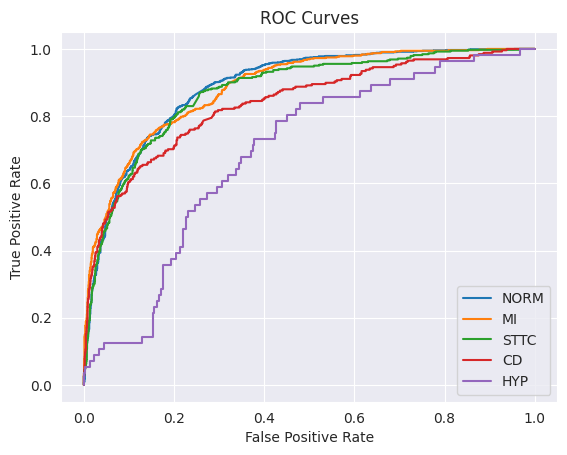

In [ ]:
# ROC curves per class
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred[:, i])
    plt.plot(fpr, tpr, label=name)
plt.legend()
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

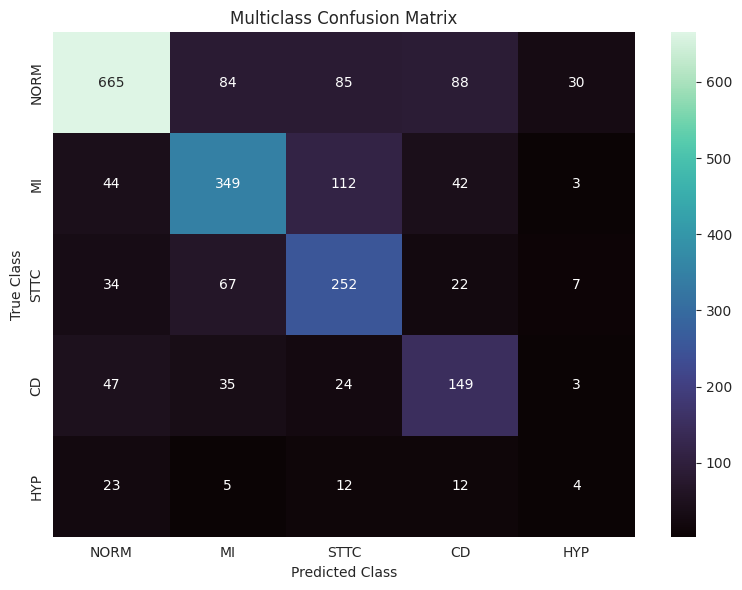

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true_cls, y_pred_cls)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='mako',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Multiclass Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()